# Lab Instructions

Create 3 visualizations from text data of your choice.  Each visualization should have at least 1 - 2 sentences explaining both the figure and the interpretation.
You may use any LLM and produce whatever visuals you think best illustrate your data.  

In [3]:
import pandas as pd
from wordcloud import WordCloud
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)
from collections import Counter
import string
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS as sklearn_stop_words


df = pd.read_csv('Airline_Reviews_Combined.csv')

df.head()

,NAMES,Title,Author,Country,Date,Verified,Review,Type Of Traveller,Seat Type,Route,Date Flown,Seat Comfort,Cabin Staff Service,Food & Beverages,Inflight Entertainment,Ground Service,Wifi & Connectivity,Value For Money,Recommended,Aircraft
0,AB Aviation,"""pretty decent airline""",Tom Hansen,Netherlands,11th November 2019,True,✅Trip Verified| Moroni to Moheli. Turned out ...,Solo Leisure,Economy Class,Moroni to Moheli,November 2019,4.0,5.0,4.0,NaN,4.0,NaN,3.0,yes,NaN
1,AB Aviation,"""Not a good airline""",Gyan Fernando,United Kingdom,25th June 2019,True,✅Trip Verified| Moroni to Anjouan. It is a ver...,Solo Leisure,Economy Class,Moroni to Anjouan,June 2019,2.0,2.0,1.0,NaN,1.0,NaN,2.0,no,E120
2,AB Aviation,"""flight was fortunately short""",Gyan Fernando,United Kingdom,25th June 2019,True,✅Trip Verified| Anjouan to Dzaoudzi. A very s...,Solo Leisure,Economy Class,Anjouan to Dzaoudzi,June 2019,2.0,1.0,1.0,NaN,1.0,NaN,2.0,no,Embraer E120
3,Adria Airways,"""I will never fly again with Adria""",D Praetextatus,Serbia,28th September 2019,False,Not Verified| Please do a favor yourself and ...,Solo Leisure,Economy Class,Frankfurt to Pristina,September 2019,1.0,1.0,NaN,NaN,1.0,NaN,1.0,no,NaN
4,Adria Airways,"""it ruined our last days of holidays""",D Meijer,Netherlands,24th September 2019,True,✅Trip Verified| Do not book a flight with this...,Couple Leisure,Economy Class,Sofia to Amsterdam via Ljubljana,September 2019,1.0,1.0,1.0,1.0,1.0,1.0,1.0,no,NaN


Positive Review Titles


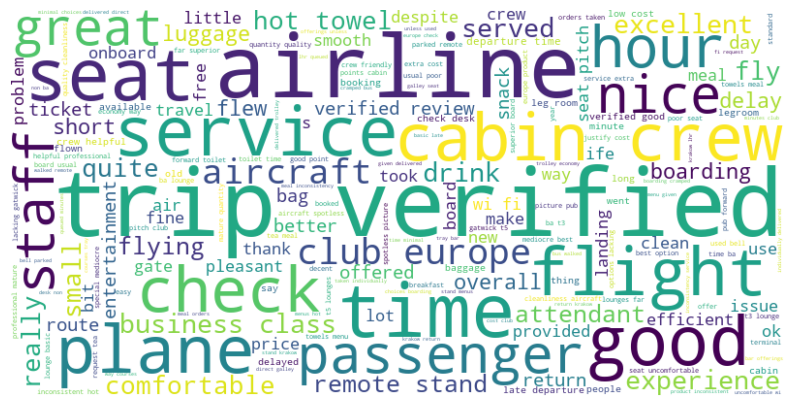

Negative Review Titles


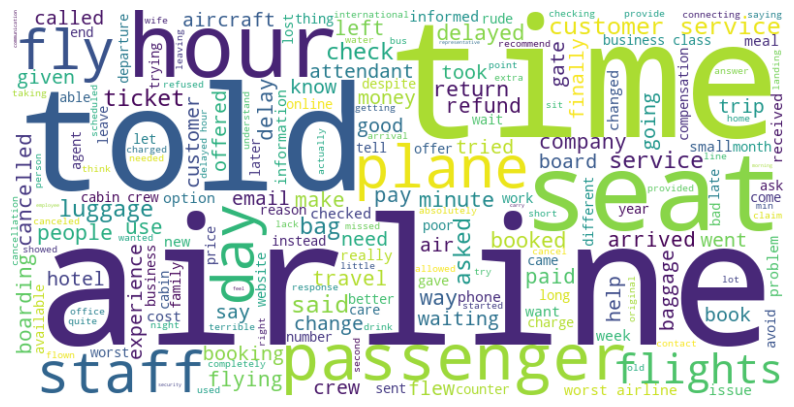

In [2]:
additional_stop_words = {'but', 'was', 'flight', 'airport', 'food', 'got'}

positive_reviews = ' '.join(df[df['Recommended'].str.lower() == 'yes']['Review'].dropna().astype(str))
negative_reviews = ' '.join(df[df['Recommended'].str.lower() == 'no']['Review'].dropna().astype(str))

positive_words = positive_reviews.lower().split()
negative_words = negative_reviews.lower().split()

postive_words = [word.strip(string.punctuation)
    for word in positive_words
    if word.strip(string.punctuation)
    and word.strip(string.punctuation) not in sklearn_stop_words
    and word.strip(string.punctuation) not in additional_stop_words]
negative_words = [word.strip(string.punctuation) for word in negative_words if word.isalnum() and word not in sklearn_stop_words and word not in additional_stop_words]

print('Positive Review Titles')
wordcloud = WordCloud(width=800, height=400, background_color ='white').generate(' '.join(postive_words))
plt.figure(figsize=(10, 7)) 
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.show()

print('Negative Review Titles')
wordcloud = WordCloud(width=800, height=400, background_color ='white').generate(' '.join(negative_words))
plt.figure(figsize=(10, 7)) 
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.show()

In [4]:
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)
from textblob import TextBlob
import plotly.express as px

df['review_length'] = df['Review'].str.len()

fig = px.box(df,
             x='Recommended',
             y='review_length')

fig.update_layout(title='Flight Review Text Length by Recommendation')

fig.show()

c:\Users\arnul\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:152: UserWarning:

Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from current font.



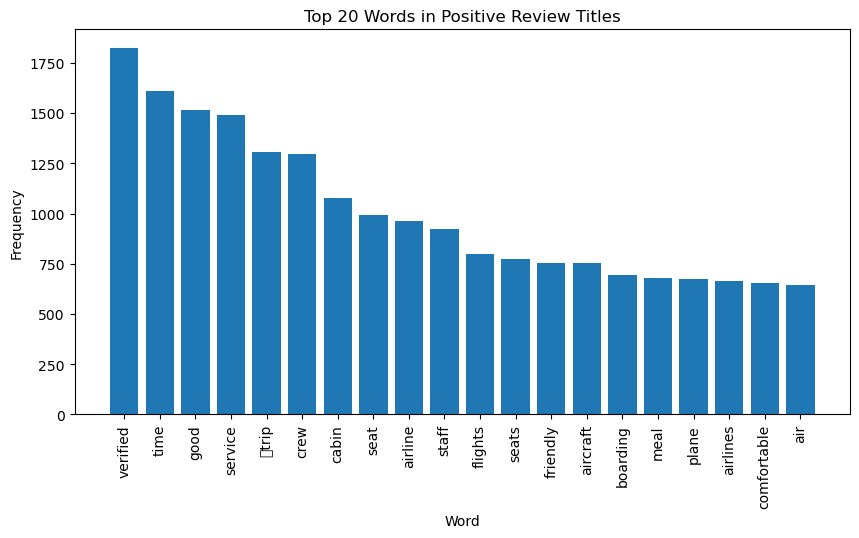

In [14]:
import seaborn as sns
positive_word_freq = Counter(postive_words)
positive_common_words = positive_word_freq.most_common(20)
    
# Convert to DataFrame for plotting
positive_freq_df = pd.DataFrame(positive_common_words, columns=['Word', 'Frequency'])
    
fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(positive_freq_df['Word'], positive_freq_df['Frequency'])
ax.set_title(f'Top 20 Words in Positive Review Titles')
ax.set_xlabel('Word')
ax.set_ylabel('Frequency')
plt.xticks(rotation=90)
plt.show()

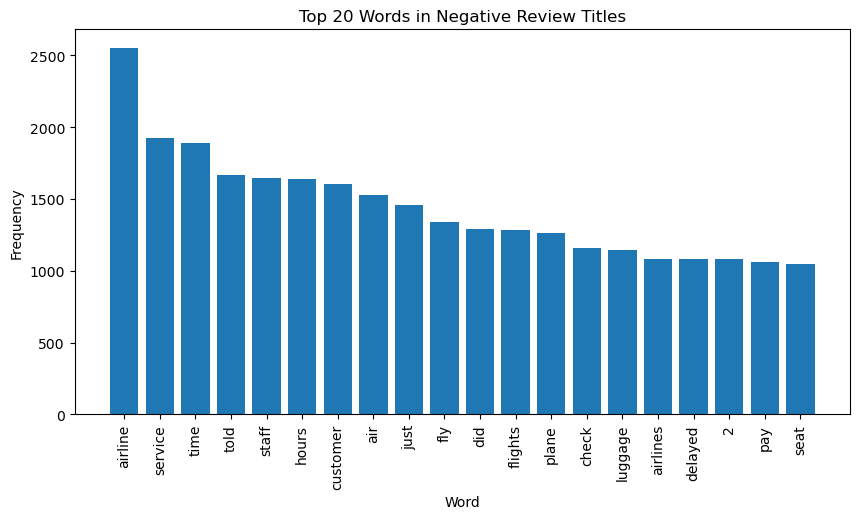

In [10]:
import seaborn as sns

negative_word_freq = Counter(negative_words)
negative_common_words = negative_word_freq.most_common(20)
    
# Convert to DataFrame for plotting
negative_freq_df = pd.DataFrame(negative_common_words, columns=['Word', 'Frequency'])
    
fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(negative_freq_df['Word'], negative_freq_df['Frequency'])
ax.set_title(f'Top 20 Words in Negative Review Titles')
ax.set_xlabel('Word')
ax.set_ylabel('Frequency')
plt.xticks(rotation=90)
plt.show()